<p class="mlx-kicker">Part II &middot; Architecture &middot; Chapter 5</p>

# 5. Channel mixing: from the sigmoid MLP to Mixture of Experts

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 20 min</dd></div><div><dt>Hands-on</dt><dd>about 8 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, derivatives and the chain rule</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/05-channel-mixing/index.ipynb)

![The three generations of feed-forward layer. Each column highlights the one part that is new: a non-saturating activation, a multiplicative gate, and a router that sends each token to a few experts.](figures/ffn-lineage.svg)

## What changed, and why it works

Attention moves information *between* tokens. The feed-forward layer (FFN) then transforms each token *on its own*, and it holds about two thirds of a Transformer's parameters. It behaves like a large key-value memory: the first projection detects patterns in the token, and the second writes a matching update back (Geva et al., 2021). **[likely]** Each generation in Figure 5.1 changes one part of it.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; MLP</p><h3>A non-saturating activation</h3><p><b>What changed.</b> The sigmoid between the two projections was replaced by ReLU, then by smooth versions of it (GELU, Swish).</p><p><b>Why it works.</b> Backpropagation multiplies the gradient by the activation's slope at every layer. The sigmoid's slope is at most 1/4, so the signal shrinks layer after layer. ReLU's slope is exactly 1 wherever a unit is active, so deep stacks keep learning. GELU rounds off the corner, so no unit is ever permanently switched off.</p><p class="mlx-why__run">Our runs: sigmoid 1.839, ReLU 1.725, GELU 1.736</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; SwiGLU</p><h3>A multiplicative gate</h3><p><b>What changed.</b> A second projection multiplies the activated one, channel by channel. The hidden width shrinks from 4d to 8d/3, so the parameter count stays the same.</p><p><b>Why it works.</b> A product of two projections can respond to two input directions at once, which one activation of one projection cannot. The gate also lets each token turn channels on and off smoothly, like choosing which part of the memory to read. Nobody has a settled explanation yet. <b>[likely]</b></p><p class="mlx-why__run">Our run: 1.694 at the same parameter count</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Mixture of Experts</p><h3>Route each token to a few experts</h3><p><b>What changed.</b> One FFN became E expert FFNs, plus a small router that sends each token to its top k.</p><p><b>Why it works.</b> If the FFN is the model's memory, more parameters means more memory. A router lets the memory grow with E while each token still reads only k experts, so the compute per token stays flat. A balancing loss keeps every expert in use.</p><p class="mlx-why__run">Our run: 1.668 with about 3&times; the parameters at the same compute</p></section>
</div>

Read left to right, the pressure moves from *can we train it at all*, to *quality per parameter*, to *quality per unit of compute*. The steps below rebuild each change and test it.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1980s-2000s | Sigmoid and tanh MLPs | minor | smooth, bounded activations borrowed from neuroscience |
| 2010-2012 | ReLU | **major** | `max(0, x)`: gradient of exactly 1 for active units |
| 2016-2017 | GELU, Swish | **major** (with ReLU) | smooth ReLU-like curves; GELU becomes the default in BERT and GPT |
| 2020 | SwiGLU | minor | a gated MLP; now standard in LLMs |
| 2017, then 2021-2024 | Mixture of Experts | **major** | many FFNs, each token routed to a few |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| sigmoid to ReLU | gradients vanished in deep stacks | trainable depth, faster training, cheap compute |
| ReLU to GELU and Swish | a sharp corner and dead units | a smoother function for the optimizer, no dead units |
| plain MLP to SwiGLU | squeezing more out of each parameter | better loss at equal size, for unclear reasons |
| dense to Mixture of Experts | compute cost of scaling parameters | parameters grow without compute growing |

Read top to bottom, the pressure moves from *can we train it at all* to *how much quality per parameter* to *how much quality per FLOP*. That shift mirrors the field as a whole: once deep networks could be trained reliably, the binding constraint became compute.

**Still open:** why multiplicative gating helps so consistently; how to balance experts without an auxiliary loss distorting training (DeepSeek-V3 replaced it with a per-expert bias); and whether the FFN-as-memory view explains how facts are actually stored.


## Run it yourself

The steps share this setup: the TinyShakespeare data and the chapter 1 model, whose feed-forward layer each step swaps out. Every experiment runs on a laptop CPU in a few minutes.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
from mlexp.transformer import SwiGLU, TransformerLM

torch.set_num_threads(4)
tok, train_ids, val_ids = mlexp.load_char_corpus()

### Step 1 (minor): sigmoid and tanh

The original MLPs used the **sigmoid** `1 / (1 + e^-x)` or **tanh**. Both squash their input into a bounded range, which seemed natural (a neuron is either firing or not) and kept activations from blowing up.

The problem, known as the **vanishing gradient**, appears when you stack them. Backpropagation multiplies the gradient by the activation's derivative at every layer. The sigmoid's derivative is at most 0.25, so after 20 layers the gradient reaching the first layer is shrunk by a factor of at least 0.25^20, about 10^-12. The early layers simply stop learning.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: why sigmoid gradients vanish</p><div class="mlx-eq">$$\sigma'(x) = \sigma(x)\,\big(1 - \sigma(x)\big) \le \tfrac{1}{4} \quad\Longrightarrow\quad \prod_{l=1}^{20} \sigma'(z_l) \le 4^{-20} \approx 10^{-12}$$</div><p class="mlx-eq__where">Backpropagation multiplies one factor \(\sigma'(z_l)\) per layer, so the bound compounds with depth.</p></div>


We can measure this directly: build a 20-layer MLP, push a batch through, and record the gradient norm at each layer. Each activation gets the initialization designed for it (Xavier for sigmoid and tanh, He for ReLU; chapter 11 covers why).

sigmoid (Xavier init)  first layer / last layer = 2.1e-13
tanh (Xavier init)     first layer / last layer = 1.0e+00
ReLU (He init)         first layer / last layer = 3.1e-01


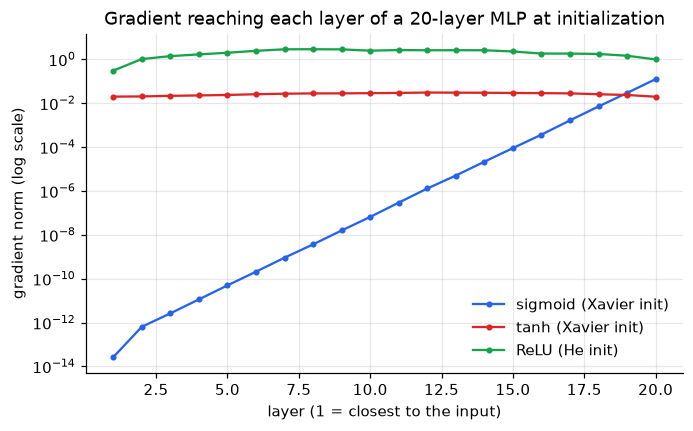

In [3]:
def gradient_per_layer(act, init, depth=20, width=256):
    torch.manual_seed(0)
    layers = [nn.Linear(width, width) for _ in range(depth)]
    for layer in layers:
        init(layer.weight)
        nn.init.zeros_(layer.bias)
    h = torch.randn(512, width)
    for layer in layers:
        h = act(layer(h))
    loss = (h - torch.randn_like(h)).pow(2).mean()
    loss.backward()
    return [layer.weight.grad.norm().item() for layer in layers]


xavier = nn.init.xavier_normal_
he = lambda w: nn.init.kaiming_normal_(w, nonlinearity="relu")
curves = {
    "sigmoid (Xavier init)": gradient_per_layer(torch.sigmoid, xavier),
    "tanh (Xavier init)": gradient_per_layer(torch.tanh, xavier),
    "ReLU (He init)": gradient_per_layer(F.relu, he),
}

fig, ax = plt.subplots()
for name, g in curves.items():
    ax.semilogy(range(1, 21), g, marker="o", ms=3, label=name)
ax.set(xlabel="layer (1 = closest to the input)", ylabel="gradient norm (log scale)",
       title="Gradient reaching each layer of a 20-layer MLP at initialization")
ax.legend(frameon=False);
for name, g in curves.items():
    print(f"{name:22s} first layer / last layer = {g[0] / g[-1]:.1e}")

The sigmoid's gradient collapses by about 13 orders of magnitude across 20 layers. Tanh, which is centred on zero and has derivative 1 at the origin, survives at initialization, but it saturates once activations grow during training, and then it suffers the same way. ReLU keeps the gradient within a small factor across all 20 layers.

### Step 2 (major): ReLU, GELU and Swish

#### The idea

The **rectified linear unit**, `ReLU(x) = max(0, x)`, was popularized for deep networks by Nair and Hinton (2010) and Glorot et al. (2011), and made famous by AlexNet (2012), which trained several times faster with it than with tanh. For an active unit its derivative is exactly 1, so gradients pass through unchanged. It is also nearly free to compute, and it makes activations sparse: about half the units output exactly zero.

ReLU has a known flaw: a unit whose input is always negative gets zero gradient forever, a **dead ReLU**. Its successors keep the ReLU shape but smooth the corner:

- **GELU** (Hendrycks and Gimpel, 2016): `x * Phi(x)`, where Phi is the Gaussian cumulative distribution. It weights the input by how likely it is to be positive. BERT and GPT-2 adopted it, and it became the Transformer default.
- **Swish**, also called **SiLU** (Ramachandran et al., 2017): `x * sigmoid(x)`. It was found by an automated search over candidate activation functions, and is nearly identical in shape to GELU.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: the ReLU family</p><div class="mlx-eq">$$\mathrm{ReLU}(x) = \max(0, x), \qquad \mathrm{GELU}(x) = x\,\Phi(x), \qquad \mathrm{Swish}(x) = x\,\sigma(x)$$</div><p class="mlx-eq__where">\(\Phi\) is the standard Gaussian cumulative distribution and \(\sigma\) the sigmoid.</p></div>

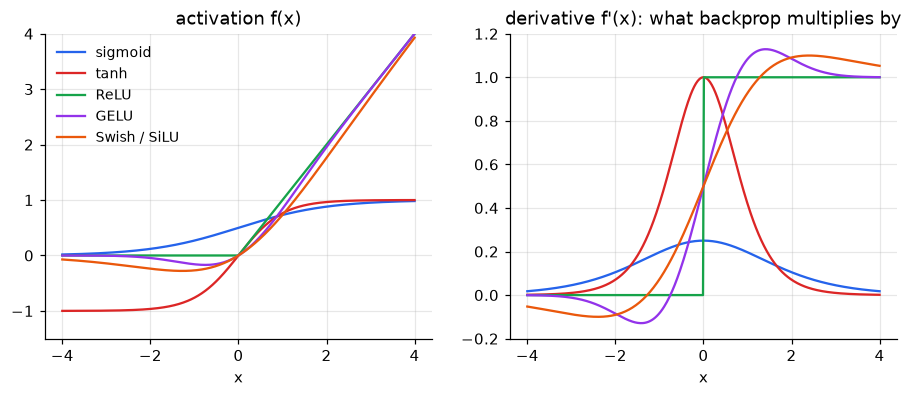

In [4]:
x = torch.linspace(-4, 4, 400, requires_grad=True)
acts = {"sigmoid": torch.sigmoid, "tanh": torch.tanh, "ReLU": F.relu, "GELU": F.gelu, "Swish / SiLU": F.silu}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
for name, f in acts.items():
    y = f(x)
    (dy,) = torch.autograd.grad(y.sum(), x)
    ax1.plot(x.detach(), y.detach(), label=name)
    ax2.plot(x.detach(), dy, label=name)
ax1.set(title="activation f(x)", xlabel="x", ylim=(-1.5, 4))
ax2.set(title="derivative f'(x): what backprop multiplies by", xlabel="x", ylim=(-0.2, 1.2))
ax1.legend(frameon=False, fontsize=9);

The right panel is the whole story of step 1 and 2. The sigmoid's derivative never exceeds 0.25. ReLU's is exactly 1 for positive inputs and 0 otherwise. GELU and Swish follow ReLU for large inputs but are smooth near zero, slightly negative for small negative inputs, and never exactly zero, so no unit is ever permanently dead.

### Step 3 (minor): SwiGLU

#### The idea

A **gated linear unit** (Dauphin et al., 2016) computes two projections of the input and multiplies them element by element: one acts as content, the other, passed through an activation, decides how much of each channel gets through. Shazeer (2020) tried this with several activations inside the Transformer FFN and found **SwiGLU** (the Swish-gated version) worked best. LLaMA, PaLM, Mistral, DeepSeek and most current LLMs use it.

A gated FFN has three weight matrices instead of two. To compare fairly, its hidden width is shrunk from `4d` to `8d/3`, so the parameter count stays the same.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the SwiGLU feed-forward layer</p><div class="mlx-eq">$$\mathrm{FFN}_{\mathrm{SwiGLU}}(x) = W_{\text{down}}\big(\mathrm{Swish}(W_{\text{gate}}\,x) \odot W_{\text{up}}\,x\big)$$</div><p class="mlx-eq__where">\(\odot\) is element-wise multiplication. Three matrices of size \(d \times \tfrac{8d}{3}\) hold \(8d^2\) parameters, the same as two matrices of size \(d \times 4d\).</p></div>

In [5]:
class SwiGLU(nn.Module):
    """Feed-forward layer: a gated MLP applied to each token independently."""

    def __init__(self, dim: int, hidden: int | None = None):
        super().__init__()
        hidden = hidden or int(8 * dim / 3)  # keeps parameters equal to a 4x ReLU MLP
        self.gate = nn.Linear(dim, hidden, bias=False)
        self.up = nn.Linear(dim, hidden, bias=False)
        self.down = nn.Linear(hidden, dim, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))

In [6]:
class MLP(nn.Module):
    """The classic two-layer FFN: up-project, activation, down-project."""

    def __init__(self, dim, act, hidden=None):
        super().__init__()
        hidden = hidden or 4 * dim
        self.up = nn.Linear(dim, hidden, bias=False)
        self.down = nn.Linear(hidden, dim, bias=False)
        self.act = act

    def forward(self, x):
        return self.down(self.act(self.up(x)))


print(f"ReLU MLP params per layer: {mlexp.count_params(MLP(128, F.relu)):,}")
print(f"SwiGLU params per layer:   {mlexp.count_params(SwiGLU(128)):,}")

ReLU MLP params per layer: 131,072
SwiGLU params per layer:   130,944


#### Experiment: four FFNs, same parameter budget

We train the chapter 1 language model four times, changing only the FFN: sigmoid MLP, ReLU MLP, GELU MLP and SwiGLU. Everything else, including the seed and the data order, is identical. Each run takes about a minute on CPU.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">All four FFNs have about 804,000 parameters. Rank the sigmoid MLP, ReLU MLP, GELU MLP and SwiGLU by final validation loss.</p><details><summary>Show what happened</summary><p>SwiGLU is best (1.694). ReLU (1.725) and GELU (1.736) are nearly tied, and the sigmoid MLP trails clearly (1.839).</p></details></div>

sigmoid MLP  params 804,224  final val loss 1.839


ReLU MLP     params 804,224  final val loss 1.725


GELU MLP     params 804,224  final val loss 1.736


SwiGLU       params 803,712  final val loss 1.694


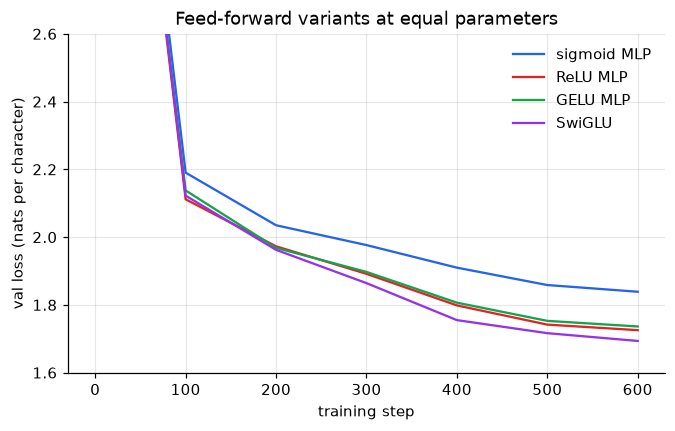

In [7]:
variants = {
    "sigmoid MLP": lambda d: MLP(d, torch.sigmoid),
    "ReLU MLP": lambda d: MLP(d, F.relu),
    "GELU MLP": lambda d: MLP(d, F.gelu),
    "SwiGLU": lambda d: SwiGLU(d),
}
histories = {}
for name, make_ffn in variants.items():
    torch.manual_seed(0)
    model = TransformerLM(tok.vocab_size, dim=128, n_layers=4, n_heads=4, make_ffn=make_ffn)
    histories[name] = mlexp.train_lm(model, train_ids, val_ids, steps=600, block_size=64, eval_every=100, log=False)
    print(f"{name:12s} params {mlexp.count_params(model):,}  final val loss {histories[name]['val'][-1]:.3f}")

ax = mlexp.plot_histories(histories, "Feed-forward variants at equal parameters")
ax.set_ylim(1.6, 2.6);

#### Why it worked: a post-mortem

**Sigmoid loses clearly**, even in a model only 4 blocks deep, because its small derivatives slow learning in every FFN. **[established]**

**ReLU and GELU are roughly tied at this scale.** The published gains from GELU are small and appear mainly in larger models trained for longer. Its likely advantages are a smoother loss surface for adaptive optimizers and no permanently dead units, though in our run no ReLU unit died either. **[likely]**, and worth noting that GELU's adoption was driven as much by BERT's success as by head-to-head ablations.

**SwiGLU wins at equal parameters.** That matches Shazeer (2020) and later replications at much larger scale. Why it wins is still open. Shazeer's own paper is unusually candid: "We offer no explanation as to why these architectures seem to work; we attribute their success, as all else, to divine benevolence." The current best guesses are:

- **Multiplicative interactions.** A product of two learned projections can represent a feature that depends on two input directions together, which a single activation of one projection cannot do. **[likely]**
- **Input-dependent gating.** The gate lets each token switch channels on and off smoothly, a soft version of choosing which part of the memory to read. **[speculative]**

### Step 4 (major): Mixture of Experts

#### The problem before

A dense FFN uses every parameter for every token. Scaling laws (chapter 12) say bigger models are better, but in a dense model doubling the parameters doubles the compute for every token. Is all that capacity needed for every token? A comma and a chemistry term probably need different knowledge.

#### The idea

Replace the single FFN with `E` smaller FFNs, the **experts**, and add a tiny **router** that scores the experts for each token. Each token is processed by only its top `k` experts, and their outputs are mixed using the router's weights. Total parameters grow with `E`; compute per token grows only with `k`.

Shazeer et al. (2017) introduced this sparsely gated design for LSTMs. Switch Transformer (Fedus et al., 2021) simplified it to top-1 routing at scale, and Mixtral (2023) and DeepSeek-V2 and V3 (2024) made it the standard design for open frontier models.

The catch is **load balancing**. A router that starts favouring one expert sends it more tokens, so that expert improves fastest and gets favoured even more. The fix used by Switch Transformer is an auxiliary loss that is smallest when tokens are spread evenly: for each expert, multiply the fraction of tokens it received by its mean router probability, then sum.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: routing and load balancing</p><div class="mlx-eq">$$y = \sum_{i \in \mathrm{TopK}(p(x))} \frac{p_i(x)}{\sum_{j \in \mathrm{TopK}} p_j(x)}\, \mathrm{FFN}_i(x), \qquad \mathcal{L}_{\text{aux}} = E \sum_{i=1}^{E} f_i\, P_i$$</div><p class="mlx-eq__where">\(p(x)\) is the router's softmax over the \(E\) experts, \(f_i\) the fraction of tokens sent to expert \(i\), and \(P_i\) its mean router probability. \(\mathcal{L}_{\text{aux}}\) equals \(1\) when tokens are spread evenly.</p></div>


#### Minimal implementation

The loop over experts is written for clarity, not speed. Production code groups tokens by expert and runs them in parallel.

In [8]:
class MoE(nn.Module):
    """Sparse Mixture of Experts: a router sends each token to its top-k SwiGLU experts."""

    def __init__(self, dim, n_experts=8, top_k=2, hidden=None, balance=0.01):
        super().__init__()
        self.n_experts, self.top_k, self.balance = n_experts, top_k, balance
        hidden = hidden or int(8 * dim / 3) // top_k  # k active experts cost the same as one dense FFN
        self.router = nn.Linear(dim, n_experts, bias=False)
        self.experts = nn.ModuleList(SwiGLU(dim, hidden) for _ in range(n_experts))

    def forward(self, x):
        B, T, C = x.shape
        flat = x.reshape(-1, C)
        probs = F.softmax(self.router(flat), dim=-1)  # (tokens, experts)
        weights, chosen = probs.topk(self.top_k, dim=-1)  # keep the k best experts per token
        weights = weights / weights.sum(-1, keepdim=True)

        out = torch.zeros_like(flat)
        for e, expert in enumerate(self.experts):
            rows, slot = (chosen == e).nonzero(as_tuple=True)  # tokens routed to expert e
            if len(rows):
                out.index_add_(0, rows, weights[rows, slot, None] * expert(flat[rows]))

        # Load balancing (Switch Transformer): smallest when tokens spread evenly over experts
        usage = F.one_hot(chosen, self.n_experts).float().sum(1).mean(0) / self.top_k
        self.usage = usage.detach()
        self.aux_loss = self.balance * self.n_experts * (usage * probs.mean(0)).sum()
        return out.view(B, T, C)


dense, moe = SwiGLU(128), MoE(128)
print(f"dense SwiGLU: {mlexp.count_params(dense):,} params, all used per token")
active = mlexp.count_params(moe.router) + 2 * mlexp.count_params(moe.experts[0])
print(f"MoE 8 experts, top-2: {mlexp.count_params(moe):,} params, {active:,} used per token")

dense SwiGLU: 130,944 params, all used per token
MoE 8 experts, top-2: 523,264 params, 131,584 used per token


#### Experiment: more parameters at the same compute

We train two MoE models, one with the balancing loss and one without, and compare them with the SwiGLU run above. Each MoE layer has 4 times the FFN parameters of the dense model, but each token uses about the same amount of computation. The MoE runs take about two minutes each, because of the simple loop.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The MoE has about three times the parameters of the dense model but does about the same work per token. Will it beat dense SwiGLU, and what happens when the balancing loss is switched off?</p><details><summary>Show what happened</summary><p>The balanced MoE wins (1.668 against 1.694). Without the balancing loss it is slightly worse (1.680), and expert usage becomes lopsided: some experts receive over a third of the tokens while others get almost none.</p></details></div>

MoE 8x top-2             params 2,372,992  final val loss 1.668


MoE, no balancing loss   params 2,372,992  final val loss 1.680


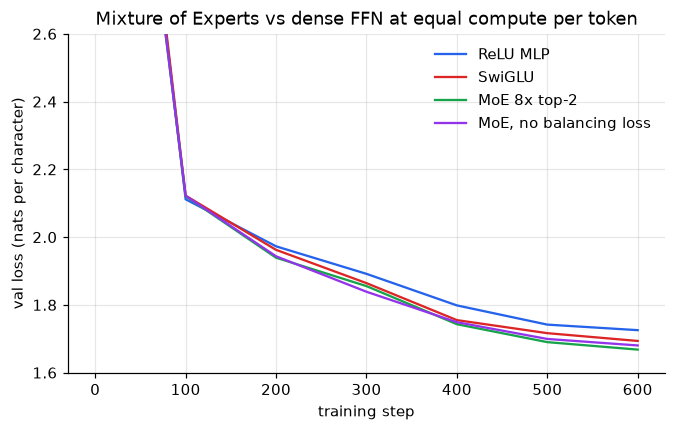

In [9]:
moe_models = {}
for name, balance in [("MoE 8x top-2", 0.01), ("MoE, no balancing loss", 0.0)]:
    torch.manual_seed(0)
    model = TransformerLM(tok.vocab_size, dim=128, n_layers=4, n_heads=4,
                          make_ffn=lambda d, b=balance: MoE(d, balance=b))
    histories[name] = mlexp.train_lm(model, train_ids, val_ids, steps=600, block_size=64, eval_every=100, log=False)
    moe_models[name] = model
    print(f"{name:24s} params {mlexp.count_params(model):,}  final val loss {histories[name]['val'][-1]:.3f}")

ax = mlexp.plot_histories({k: histories[k] for k in ["ReLU MLP", "SwiGLU", "MoE 8x top-2", "MoE, no balancing loss"]},
                          "Mixture of Experts vs dense FFN at equal compute per token")
ax.set_ylim(1.6, 2.6);

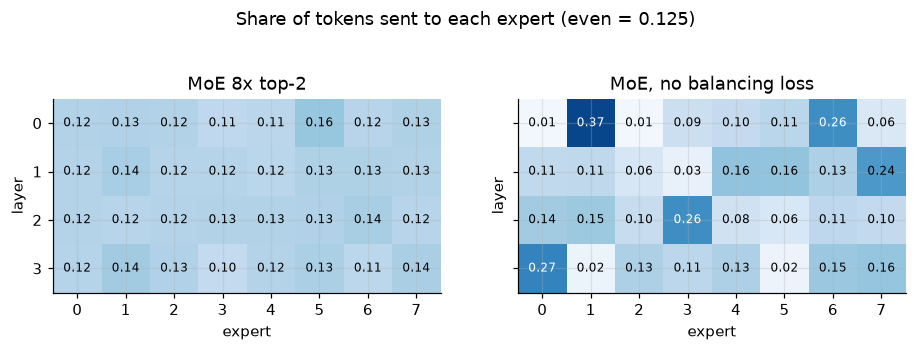

In [10]:
x, _ = mlexp.get_batch(val_ids, 64, 64, torch.Generator().manual_seed(0))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (name, model) in zip(axes, moe_models.items()):
    with torch.no_grad():
        model(x)
    usage = torch.stack([b.ffn.usage for b in model.blocks])  # (layers, experts)
    im = ax.imshow(usage, cmap="Blues", vmin=0, vmax=0.4)
    ax.set(title=name, xlabel="expert", ylabel="layer", xticks=range(8), yticks=range(4))
    for (i, j), v in np.ndenumerate(usage.numpy()):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.25 else "black")
fig.suptitle("Share of tokens sent to each expert (even = 0.125)", y=1.02);

#### Why it worked: a post-mortem

**More parameters at the same compute help.** The balanced MoE reaches a lower loss than the dense SwiGLU while doing about the same work per token. This is the core MoE result, and it holds from our toy model up to DeepSeek-V3, which has 671 billion parameters but activates 37 billion per token. **[established]**

**Without balancing, the router plays favourites.** With the auxiliary loss, every expert gets close to its fair share of 0.125. Without it, some experts get several times their share and others are nearly idle, so part of the model's capacity is wasted. In our small run the unbalanced model is only slightly worse; at scale, collapse and the resulting instability are a major practical problem, and Switch Transformer and its successors spend much of their engineering effort on it. **[established]**

**Do experts specialize in topics?** Less than the name suggests. Studies of Mixtral found routing follows syntax and token type (punctuation, code indentation) more than subject matter. **[likely]** Whether finer-grained experts (DeepSeekMoE) lead to more meaningful specialization is an open question. **[speculative]**

**Caveat on our numbers.** These are single runs with one seed on a tiny model. Differences of a few hundredths in loss can flip with a different seed. The direction of each result matches the published literature, which is why we trust it, but treat the exact gaps as illustrations rather than measurements.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Explain why stacked sigmoid layers lose their gradient, and measure it.</li><li>Write ReLU, GELU, Swish and SwiGLU as formulas and compare their shapes.</li><li>Implement a top-k Mixture of Experts layer with a load-balancing loss.</li><li>Separate what is established about feed-forward layers from what is still a guess.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>Why does the gradient vanish through 20 sigmoid layers but not through 20 ReLU layers?</summary><p>Each layer multiplies the gradient by the activation's derivative. The sigmoid's is at most 1/4, so the product shrinks geometrically. ReLU's derivative is exactly 1 for every active unit.</p></details><details><summary>SwiGLU's hidden width is 8d/3 instead of 4d. Where does 8/3 come from?</summary><p>SwiGLU has three weight matrices instead of two. Three matrices of d by 8d/3 hold 8d&sup2; parameters, the same as two matrices of d by 4d, so the comparison is fair.</p></details><details><summary>In an MoE layer with 8 experts and top-2 routing, how do parameters and per-token compute compare with a single expert?</summary><p>Parameters grow about 8 times, because all experts are stored. Compute per token grows about 2 times, because each token visits only 2 experts, plus a tiny router.</p></details><details><summary>What goes wrong when the router is trained without a balancing loss?</summary><p>Rich get richer: an expert that receives more tokens improves faster and gets chosen even more. Some experts sit idle, so their parameters are wasted, and at scale this can destabilise training.</p></details></div>

## Further reading

- Glorot and Bengio, 2010, [Understanding the difficulty of training deep feedforward neural networks](https://proceedings.mlr.press/v9/glorot10a.html): vanishing gradients and Xavier initialization.
- Nair and Hinton, 2010, [Rectified Linear Units Improve Restricted Boltzmann Machines](https://www.cs.toronto.edu/~hinton/absps/reluICML.pdf).
- Hendrycks and Gimpel, 2016, [Gaussian Error Linear Units](https://arxiv.org/abs/1606.08415).
- Ramachandran, Zoph and Le, 2017, [Searching for Activation Functions](https://arxiv.org/abs/1710.05941): Swish.
- Shazeer, 2020, [GLU Variants Improve Transformer](https://arxiv.org/abs/2002.05202): SwiGLU.
- Geva et al., 2021, [Transformer Feed-Forward Layers Are Key-Value Memories](https://arxiv.org/abs/2012.14913).
- Shazeer et al., 2017, [Outrageously Large Neural Networks: The Sparsely-Gated Mixture-of-Experts Layer](https://arxiv.org/abs/1701.06538).
- Fedus, Zoph and Shazeer, 2021, [Switch Transformers](https://arxiv.org/abs/2101.03961).
- Jiang et al., 2024, [Mixtral of Experts](https://arxiv.org/abs/2401.04088).
- Dai et al., 2024, [DeepSeekMoE](https://arxiv.org/abs/2401.06066).